In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_validate,cross_val_score,KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder
from scipy import stats

In [2]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_df.shape

(1338, 7)

In [6]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
insurance_df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [8]:
# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'sex' column
insurance_df['sex'] = label_encoder.fit_transform(insurance_df['sex'])
insurance_df['smoker'] = label_encoder.fit_transform(insurance_df['smoker'])
insurance_df = pd.get_dummies(insurance_df, columns=['region'], drop_first=False)

# If you have other categorical columns, you can apply the same method
# insurance_df['region'] = label_encoder.fit_transform(insurance_df['region'])
# ... existing code ...

In [9]:
insurance_df.describe()

,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [10]:
insurance_df.head()


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [11]:
# Assuming X contains your features and y contains your target variable
X = insurance_df.drop('charges', axis=1)  # Replace 'charges' with your target variable
y = insurance_df['charges']  # Your target variable

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)



In [12]:
X_train.head()



,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,False,True,False,False
1285,47,0,24.32,0,0,True,False,False,False
1142,52,0,24.86,0,0,False,False,True,False
969,39,0,34.32,5,0,False,False,True,False
486,54,0,21.47,3,0,False,True,False,False


In [13]:
X_test.head()



,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
764,45,0,25.175,2,0,True,False,False,False
887,36,0,30.020,0,0,False,True,False,False
890,64,0,26.885,0,1,False,True,False,False
1293,46,1,25.745,3,0,False,True,False,False
259,19,1,31.920,0,1,False,True,False,False


In [14]:
y_train.head()


560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
Name: charges, dtype: float64

In [15]:
y_test.head()



764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
Name: charges, dtype: float64

In [16]:
X_train

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
560,46,0,19.950,2,0,False,True,False,False
1285,47,0,24.320,0,0,True,False,False,False
1142,52,0,24.860,0,0,False,False,True,False
969,39,0,34.320,5,0,False,False,True,False
486,54,0,21.470,3,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1095,18,0,31.350,4,0,True,False,False,False
1130,39,0,23.870,5,0,False,False,True,False
1294,58,1,25.175,0,0,True,False,False,False
860,37,0,47.600,2,1,False,False,False,True


In [17]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [18]:
X_train


array([[ 0.47222651, -1.0246016 , -1.75652513, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.0246016 , -1.03308239, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 0.8987451 , -1.0246016 , -0.94368672, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       ...,
       [ 1.3252637 ,  0.97598911, -0.89153925, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.16755139, -1.0246016 ,  2.82086429, ..., -0.56079971,
        -0.59966106,  1.74729228],
       [ 1.1120044 ,  0.97598911, -0.10932713, ..., -0.56079971,
        -0.59966106,  1.74729228]])

In [19]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [20]:
model = SVR(kernel='poly',C=80,epsilon=0.001,gamma=0.6)  
model.fit(X_train, y_train)  # Fit the model

SVR(C=80, epsilon=0.001, gamma=0.6, kernel='poly')

In [21]:
scores = cross_val_score(model, X_train,y_train, cv=5)
print("Cross-Validation Scores:", scores)

Cross-Validation Scores: [0.80373797 0.86677275 0.78126325 0.73540017 0.82574013]


In [22]:
print(model.predict(sc.transform([[30, 1, 28.5, 2, 0, 0, 0, 1, 0]])))  # Make a prediction)
#    predict(age, sex, bmi, children, smoker, northeast, northwest, southeast, southwest]])))  # Make a prediction

[4496.48509881]


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
y_pred =model.predict(X_test)  # Make predictions on the test set

# Convert y_test to a NumPy array for concatenation
y_test_array = y_test.to_numpy()  # Convert Series to NumPy array

# Concatenate predictions and actual values
result = np.concatenate((y_pred.reshape(len(y_pred), 1), y_test_array.reshape(len(y_test_array), 1)), axis=1)

print(result)  # Print the concatenated result
# ... existing code ...

[[ 9112.36344552  9095.06825   ]
 [ 5321.94877113  5272.1758    ]
 [26654.57959425 29330.98315   ]
 [ 9290.33984559  9301.89355   ]
 [21965.64969417 33750.2918    ]
 [ 4916.17185187  4536.259     ]
 [ 1992.10808892  2117.33885   ]
 [14233.39774981 14210.53595   ]
 [ 3938.04048393  3732.6251    ]
 [10192.90925075 10264.4421    ]
 [20465.10853103 18259.216     ]
 [ 7433.27539152  7256.7231    ]
 [ 3959.39532269  3947.4131    ]
 [48547.658968   46151.1245    ]
 [49941.15372263 48673.5588    ]
 [44606.27475155 44202.6536    ]
 [ 9929.34404342  9800.8882    ]
 [41171.09035015 42969.8527    ]
 [ 8301.98225156  8233.0975    ]
 [25847.66205245 21774.32215   ]
 [ 4805.05173307  5080.096     ]
 [ 7555.1398693   7441.501     ]
 [ 1141.85291996  1256.299     ]
 [ 2958.85304038  2755.02095   ]
 [11165.27982517 11085.5868    ]
 [10961.64987558 10923.9332    ]
 [12645.92893663 12644.589     ]
 [ 4495.90265031 18804.7524    ]
 [ 9733.41457454  9715.841     ]
 [ 1067.01171272  1131.5066    ]
 [ 8622.46

In [24]:
# Calculate regression metrics
mae = mean_absolute_error(y_test_array, y_pred)
mse = mean_squared_error(y_test_array, y_pred)
r2 = r2_score(y_test_array, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Absolute Error: 1867.7518039005386
Mean Squared Error: 21724489.234933894
R-squared: 0.8600665588299183


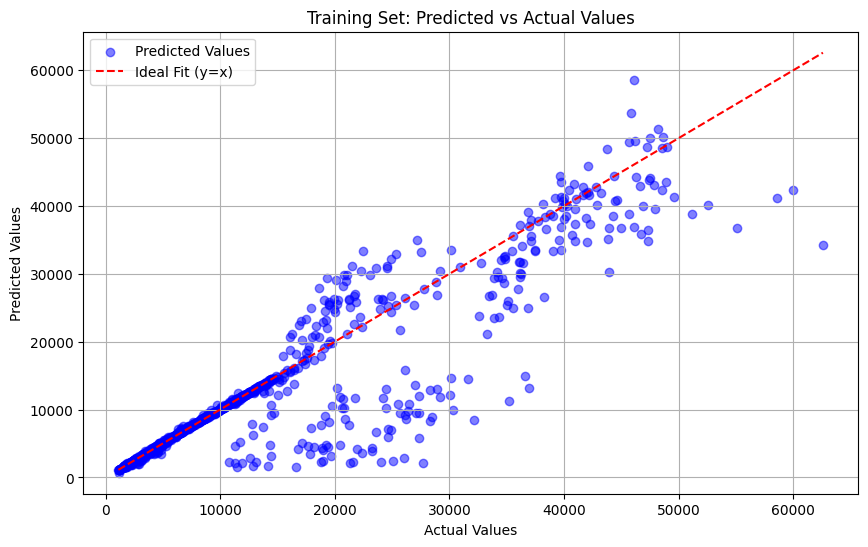

In [25]:
# Scatter plot of predictions vs actual values for the train set
plt.figure(figsize=(10, 6))
plt.scatter(y_train, model.predict(X_train), color='blue', alpha=0.5, label='Predicted Values')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', label='Ideal Fit (y=x)')  
plt.title('Training Set: Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()
plt.legend()  
plt.show()

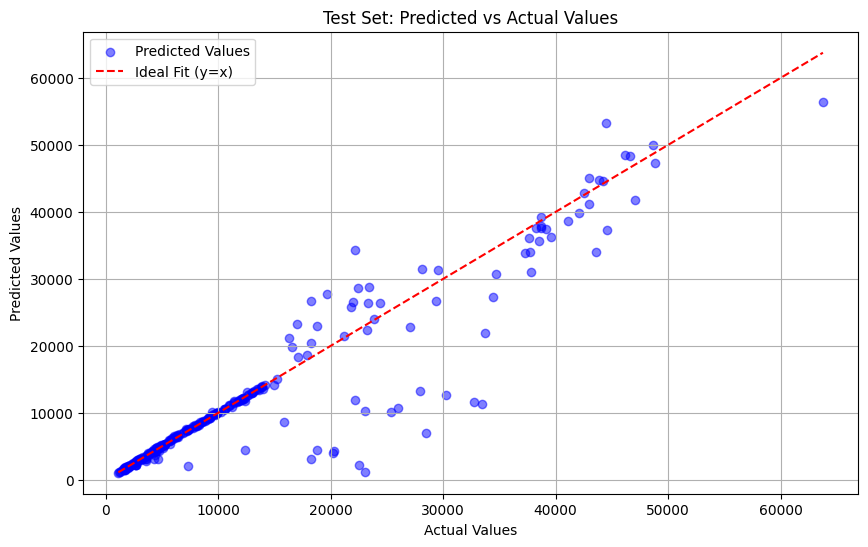

In [26]:
# Scatter plot of test set predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_array, y_pred, color='blue', alpha=0.5, label='Predicted Values')
plt.plot([y_test_array.min(), y_test_array.max()], [y_test_array.min(), y_test_array.max()], 'r--', label='Ideal Fit (y=x)')  # 45-degree line
plt.title('Test Set: Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()
plt.legend()  # Show legend
plt.show()